✓ Loaded 387,516 events  |  BG=213,041  AF=174,475
✅ Saved Fig1_spatial_overview.pdf
✅ Saved Fig2_classification_diagnostics.pdf
✅ Both figures saved (PDF + PNG).


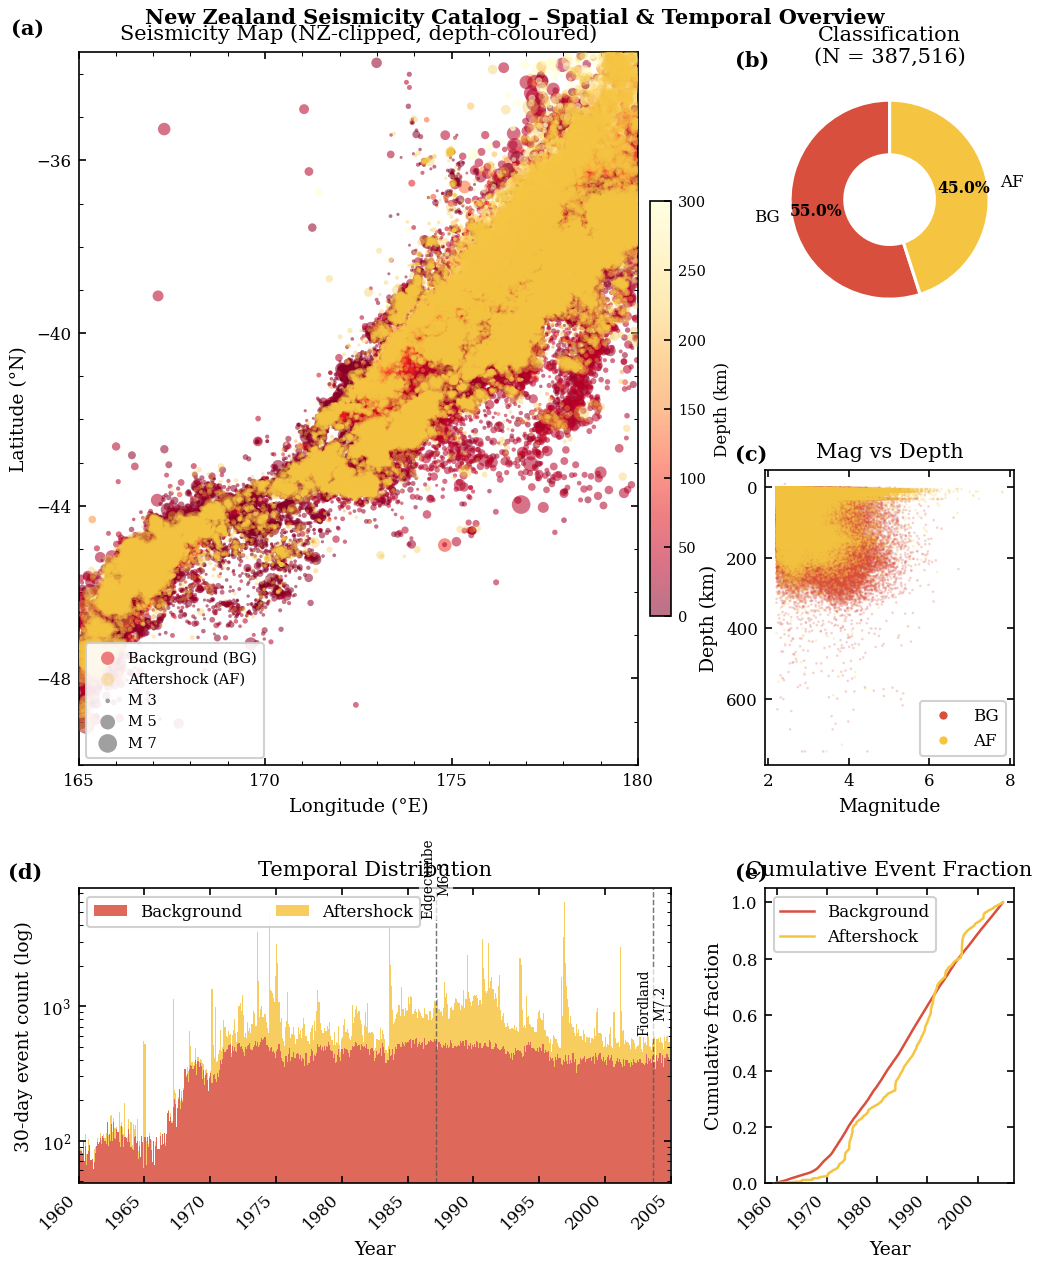

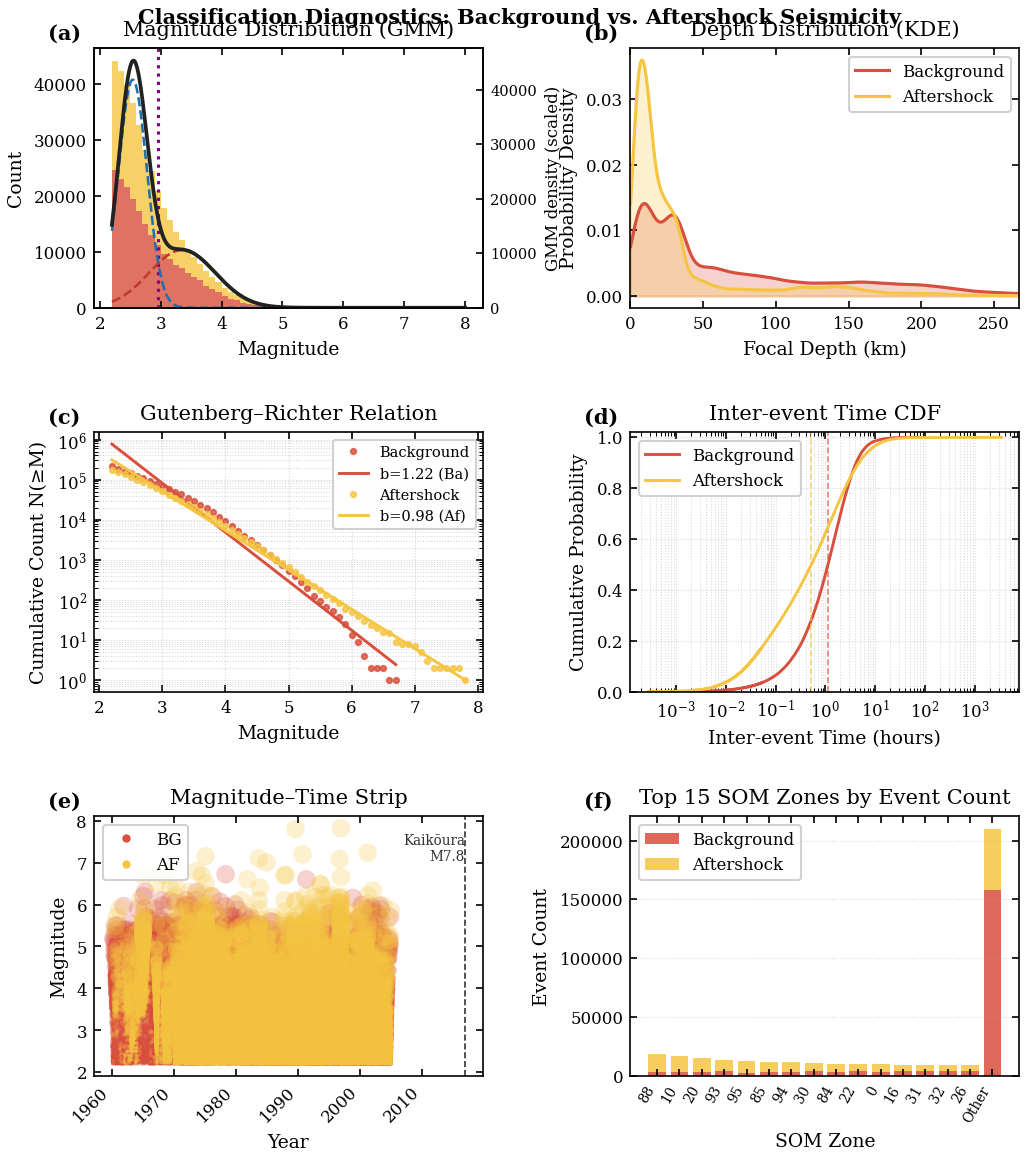

In [7]:
"""
NZ Catalog – Publication-Quality Seismicity Analysis
======================================================
Generates two multi-panel figures suitable for submission to GJI / JGR / BSSA:
  Figure 1  – Spatial & catalog overview   (3×3 panels)
  Figure 2  – Classification diagnostics   (3×2 panels)

Usage
-----
    python nz_catalog_publication.py          # uses path set in __main__
    df = run(csv_path)                        # programmatic call

Column requirements (nz_catalog_labelled.csv / NZ_catalog_labeled.csv)
-----------------------------------------------------------------------
  event, time, latitude, longitude, magnitude, depth,
  som_zone, cluster_global, event_type   (BG | AF)

The 'time' column is assumed to be fractional days since EPOCH (see below).
"""

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from scipy.stats import norm, gaussian_kde, linregress
from scipy.signal import savgol_filter
from sklearn.mixture import GaussianMixture

# ─────────────────────────────────────────────
#  Global Style  (publication-ready)
# ─────────────────────────────────────────────
FONT  = 'DejaVu Serif'          # fallback serif – matches most journal styles
mpl.rcParams.update({
    'font.family':       'serif',
    'font.serif':        [FONT, 'Times New Roman', 'Georgia'],
    'font.size':         9,
    'axes.titlesize':    10,
    'axes.labelsize':    9,
    'xtick.labelsize':   8,
    'ytick.labelsize':   8,
    'legend.fontsize':   8,
    'axes.linewidth':    0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.minor.width': 0.5,
    'ytick.minor.width': 0.5,
    'xtick.direction':   'in',
    'ytick.direction':   'in',
    'xtick.top':         True,
    'ytick.right':       True,
    'axes.spines.top':   True,
    'axes.spines.right': True,
    'figure.dpi':        150,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
    'savefig.pad_inches': 0.05,
    'pdf.fonttype':      42,       # editable text in PDFs
    'ps.fonttype':       42,
    'axes.grid':         False,
})

# ─────────────────────────────────────────────
#  Color palette
# ─────────────────────────────────────────────
C = {
    'BG':      '#D94F3D',   # warm crimson
    'AF':      '#F5C542',   # amber-gold
    'BG_dark': '#8B1A1A',
    'AF_dark': '#B8860B',
    'neutral': '#444444',
    'grey':    '#AAAAAA',
    'line':    '#222222',
}
ALPHA_FILL = 0.25

# ─────────────────────────────────────────────
#  New Zealand geographic bounds (tight)
# ─────────────────────────────────────────────
NZ_LON = (165.0, 180.0)
NZ_LAT = (-50.0, -33.5)

# Reference epoch
EPOCH = pd.Timestamp('1960-01-01')

# Major NZ events for temporal annotation
MAJOR_NZ = {
    '1987-03-02': ('Edgecumbe',     6.3),
    '2003-08-22': ('Fiordland',     7.2),
    '2009-07-15': ('Fiordland',     7.8),
    '2010-09-04': ('Darfield',      7.1),
    '2011-02-22': ('Christchurch',  6.3),
    '2013-07-21': ('Cook Strait',   6.5),
    '2016-11-14': ('Kaikōura',      7.8),
    '2021-03-05': ('Kermadec',      8.1),
}

# ═══════════════════════════════════════════════════════
#  DATA LOADING
# ═══════════════════════════════════════════════════════
def load(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()

    # Normalise event_type
    df['event_type'] = df['event_type'].astype(str).str.strip().str.upper()
    df = df[df['event_type'].isin(['BG', 'AF'])].copy()

    # Convert time → DateTime
    df['DateTime'] = EPOCH + pd.to_timedelta(df['time'].astype(float), unit='D')

    # Clip to NZ bounds (removes antipodal artefacts)
    df = df[(df['longitude'] >= NZ_LON[0]) & (df['longitude'] <= NZ_LON[1]) &
            (df['latitude']  >= NZ_LAT[0]) & (df['latitude']  <= NZ_LAT[1])].copy()

    df['depth'] = pd.to_numeric(df['depth'], errors='coerce')
    df['magnitude'] = pd.to_numeric(df['magnitude'], errors='coerce')
    df.dropna(subset=['latitude','longitude','depth','magnitude'], inplace=True)

    n_bg = (df['event_type']=='BG').sum()
    n_af = (df['event_type']=='AF').sum()
    print(f"✓ Loaded {len(df):,} events  |  BG={n_bg:,}  AF={n_af:,}")
    return df.reset_index(drop=True)


# ═══════════════════════════════════════════════════════
#  FIGURE 1 – Spatial & Catalog Overview  (3 cols × 3 rows)
# ═══════════════════════════════════════════════════════
def figure1(df: pd.DataFrame, outpath='Fig1_spatial_overview.pdf'):
    bg  = df[df['event_type']=='BG']
    af  = df[df['event_type']=='AF']

    fig = plt.figure(figsize=(18/2.54, 22/2.54))   # ~7×8.7 in → A4 column-friendly
    gs  = gridspec.GridSpec(3, 3, figure=fig,
                             hspace=0.42, wspace=0.38,
                             left=0.09, right=0.97,
                             top=0.94,  bottom=0.07)

    # ── Panel (a) Seismicity Map ──────────────────────────────────
    ax_map = fig.add_subplot(gs[0:2, 0:2])
    _panel_map(ax_map, bg, af)
    _label(ax_map, '(a)')

    # ── Panel (b) Pie / Classification summary ────────────────────
    ax_pie = fig.add_subplot(gs[0, 2])
    _panel_pie(ax_pie, bg, af)
    _label(ax_pie, '(b)')

    # ── Panel (c) Mag vs Depth cross-section ─────────────────────
    ax_cross = fig.add_subplot(gs[1, 2])
    _panel_mag_depth_cross(ax_cross, bg, af)
    _label(ax_cross, '(c)')

    # ── Panel (d) Temporal histogram ─────────────────────────────
    ax_time = fig.add_subplot(gs[2, 0:2])
    _panel_temporal(ax_time, bg, af)
    _label(ax_time, '(d)')

    # ── Panel (e) Cumulative event count ─────────────────────────
    ax_cum = fig.add_subplot(gs[2, 2])
    _panel_cumulative(ax_cum, bg, af)
    _label(ax_cum, '(e)')

    fig.suptitle('New Zealand Seismicity Catalog – Spatial & Temporal Overview',
                 fontsize=10, fontweight='bold', y=0.975)
    fig.savefig(outpath)
    print(f'✅ Saved {outpath}')
    return fig


# ═══════════════════════════════════════════════════════
#  FIGURE 2 – Classification Diagnostics  (3 × 2)
# ═══════════════════════════════════════════════════════
def figure2(df: pd.DataFrame, outpath='Fig2_classification_diagnostics.pdf'):
    bg  = df[df['event_type']=='BG']
    af  = df[df['event_type']=='AF']

    fig = plt.figure(figsize=(18/2.54, 20/2.54))
    gs  = gridspec.GridSpec(3, 2, figure=fig,
                             hspace=0.48, wspace=0.38,
                             left=0.10, right=0.97,
                             top=0.94,  bottom=0.07)

    # ── Panel (a) Magnitude distribution + GMM ───────────────────
    ax_mag = fig.add_subplot(gs[0, 0])
    _panel_magnitude_gmm(ax_mag, bg, af, df)
    _label(ax_mag, '(a)')

    # ── Panel (b) Depth distribution KDE ─────────────────────────
    ax_dep = fig.add_subplot(gs[0, 1])
    _panel_depth_kde(ax_dep, bg, af)
    _label(ax_dep, '(b)')

    # ── Panel (c) Gutenberg–Richter ───────────────────────────────
    ax_gr = fig.add_subplot(gs[1, 0])
    _panel_gutenberg_richter(ax_gr, bg, af)
    _label(ax_gr, '(c)')

    # ── Panel (d) Interevent time CDF ─────────────────────────────
    ax_iet = fig.add_subplot(gs[1, 1])
    _panel_interevent_time(ax_iet, bg, af)
    _label(ax_iet, '(d)')

    # ── Panel (e) Magnitude–time density strip ───────────────────
    ax_mt = fig.add_subplot(gs[2, 0])
    _panel_magnitude_time(ax_mt, df)
    _label(ax_mt, '(e)')

    # ── Panel (f) SOM zone composition ───────────────────────────
    ax_som = fig.add_subplot(gs[2, 1])
    _panel_som_zone(ax_som, bg, af)
    _label(ax_som, '(f)')

    fig.suptitle('Classification Diagnostics: Background vs. Aftershock Seismicity',
                 fontsize=10, fontweight='bold', y=0.975)
    fig.savefig(outpath)
    print(f'✅ Saved {outpath}')
    return fig


# ═══════════════════════════════════════════════════════
#  INDIVIDUAL PANEL FUNCTIONS
# ═══════════════════════════════════════════════════════

def _panel_map(ax, bg, af):
    """Geographic scatter — NZ-clipped, depth-coloured background."""
    # Background events: size ∝ magnitude, colour = depth
    sc_bg = ax.scatter(bg['longitude'], bg['latitude'],
                       s=_ms(bg['magnitude']),
                       c=bg['depth'],
                       cmap='YlOrRd_r', vmin=0, vmax=300,
                       alpha=0.55, ec='none', zorder=2,
                       label='Background (BG)')
    # Aftershock: semi-transparent amber
    ax.scatter(af['longitude'], af['latitude'],
               s=_ms(af['magnitude']),
               c=C['AF'], alpha=0.35, ec='none', zorder=3,
               label='Aftershock (AF)')

    # Colorbar for depth
    cb = plt.colorbar(sc_bg, ax=ax, fraction=0.035, pad=0.02, aspect=20)
    cb.set_label('Depth (km)', fontsize=8)
    cb.ax.tick_params(labelsize=7)

    ax.set_xlim(*NZ_LON)
    ax.set_ylim(*NZ_LAT)
    ax.set_xlabel('Longitude (°E)')
    ax.set_ylabel('Latitude (°N)')
    ax.set_title('Seismicity Map (NZ-clipped, depth-coloured)')
    ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
    ax.yaxis.set_major_locator(mticker.MultipleLocator(4))
    ax.xaxis.set_minor_locator(mticker.MultipleLocator(1))
    ax.yaxis.set_minor_locator(mticker.MultipleLocator(1))

    # Size legend
    for m in [3, 5, 7]:
        ax.scatter([], [], s=_ms(m), c='#888888', alpha=0.8,
                   label=f'M {m}', ec='none')
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, loc='lower left', frameon=True,
              framealpha=0.9, edgecolor='#CCCCCC', fontsize=7,
              markerscale=1, handletextpad=0.4, borderpad=0.5)


def _panel_pie(ax, bg, af):
    """Classification proportions — donut style."""
    sizes  = [len(bg), len(af)]
    colors = [C['BG'], C['AF']]
    wedges, texts, autotexts = ax.pie(
        sizes, labels=['BG', 'AF'], colors=colors,
        autopct='%1.1f%%', startangle=90,
        wedgeprops=dict(width=0.55, edgecolor='white', linewidth=1.5),
        pctdistance=0.75, labeldistance=1.12,
        textprops=dict(fontsize=8))
    for at in autotexts:
        at.set_fontsize(7.5)
        at.set_fontweight('bold')
    ax.set_title(f'Classification\n(N = {len(bg)+len(af):,})')


def _panel_mag_depth_cross(ax, bg, af):
    """Magnitude vs depth cross-section."""
    ax.scatter(bg['magnitude'], bg['depth'],
               s=1.5, alpha=0.25, c=C['BG'], ec='none', rasterized=True)
    ax.scatter(af['magnitude'], af['depth'],
               s=1.5, alpha=0.25, c=C['AF'], ec='none', rasterized=True)
    ax.invert_yaxis()
    ax.set_xlabel('Magnitude')
    ax.set_ylabel('Depth (km)')
    ax.set_title('Mag vs Depth')
    handles = [Line2D([0],[0], marker='o', color='w', markerfacecolor=C['BG'], ms=5, label='BG'),
               Line2D([0],[0], marker='o', color='w', markerfacecolor=C['AF'], ms=5, label='AF')]
    ax.legend(handles=handles, loc='lower right', frameon=True,
              framealpha=0.9, edgecolor='#CCCCCC')


def _panel_temporal(ax, bg, af, dt=30):
    """Stacked temporal histogram with major-event annotations."""
    all_dt = pd.concat([bg['DateTime'], af['DateTime']]).dropna()
    if all_dt.empty:
        ax.text(0.5, 0.5, 'No DateTime data', ha='center', va='center',
                transform=ax.transAxes)
        return

    start = all_dt.min().floor('D')
    end   = all_dt.max().ceil('D')
    bins  = pd.date_range(start, end, freq=f'{dt}D')

    ax.hist([bg['DateTime'].dropna(), af['DateTime'].dropna()],
            bins=bins, stacked=True, rwidth=1.0,
            color=[C['BG'], C['AF']], alpha=0.85,
            label=['Background', 'Aftershock'],
            edgecolor='none')
    ax.set_yscale('log')
    ax.set_xlim(start, end)
    ax.set_ylabel(f'{dt}-day event count (log)')
    ax.set_xlabel('Year')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax.legend(frameon=True, framealpha=0.9, edgecolor='#CCCCCC',
              loc='upper left', ncol=2)
    ax.set_title('Temporal Distribution')

    # Annotate major events
    ax.figure.canvas.draw()
    ymin, ymax = ax.get_ylim()
    y_ann = ymax * 0.45
    for i, (ds, (name, mag)) in enumerate(MAJOR_NZ.items()):
        dt_ = pd.to_datetime(ds)
        if not (start <= dt_ <= end):
            continue
        ax.axvline(dt_, color='#555555', lw=0.7, ls='--', alpha=0.8)
        va = 'bottom' if i % 2 == 0 else 'top'
        y_ = ymax * 0.6 if i % 2 == 0 else ymax * 0.25
        ax.text(dt_, y_, f'{name}\nM{mag}',
                rotation=90, va=va, ha='center', fontsize=6.5,
                bbox=dict(fc='white', alpha=0.7, ec='none', pad=0.8))


def _panel_cumulative(ax, bg, af):
    """Normalised cumulative event count vs time."""
    for subset, color, label in [(bg, C['BG'], 'Background'),
                                   (af, C['AF'], 'Aftershock')]:
        t = subset['DateTime'].dropna().sort_values()
        if t.empty:
            continue
        cdf = np.arange(1, len(t)+1) / len(t)
        ax.plot(t, cdf, color=color, lw=1.2, label=label)
    ax.set_ylabel('Cumulative fraction')
    ax.set_xlabel('Year')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(10))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax.set_ylim(0, 1.05)
    ax.legend(frameon=True, framealpha=0.9, edgecolor='#CCCCCC')
    ax.set_title('Cumulative Event Fraction')


# ── Figure-2 panels ──────────────────────────────────────────────────────────

def _panel_magnitude_gmm(ax, bg, af, df):
    """Magnitude histogram + 2-component GMM (publication style)."""
    mag_bins = np.arange(
        np.floor(df['magnitude'].min()*10)/10,
        np.ceil(df['magnitude'].max()*10)/10 + 0.15, 0.1)

    ax.hist([bg['magnitude'], af['magnitude']],
            bins=mag_bins, stacked=True,
            color=[C['BG'], C['AF']], alpha=0.80,
            label=['Background', 'Aftershock'], edgecolor='none')

    # 2-component GMM
    X = df['magnitude'].dropna().values.reshape(-1, 1)
    gmm = GaussianMixture(n_components=2, random_state=42, n_init=5)
    gmm.fit(X)
    means = gmm.means_.flatten()
    stds  = np.sqrt(gmm.covariances_).flatten()
    wts   = gmm.weights_.flatten()
    idx   = np.argsort(means)
    mu, sg, w = means[idx], stds[idx], wts[idx]

    x = np.linspace(mag_bins[0], mag_bins[-1], 600)
    p1 = w[0] * norm.pdf(x, mu[0], sg[0])
    p2 = w[1] * norm.pdf(x, mu[1], sg[1])
    mix= p1 + p2
    scale = len(df) * 0.1

    ax2 = ax.twinx()
    ax2.plot(x, p1*scale, ls='--', lw=1.2, color='#1a6faf',
             label=f'GMM-1 (μ={mu[0]:.2f})')
    ax2.plot(x, p2*scale, ls='--', lw=1.2, color='#c0392b',
             label=f'GMM-2 (μ={mu[1]:.2f})')
    ax2.plot(x, mix*scale, ls='-',  lw=1.8, color=C['line'],
             label='Mixture')
    ax2.set_ylabel('GMM density (scaled)', fontsize=8)
    ax2.set_ylim(bottom=0)
    ax2.tick_params(labelsize=7)

    # intersection → Mc-style threshold
    sc = np.where(np.diff(np.sign(p1 - p2)))[0]
    if len(sc):
        mc = x[sc[0]]
        ax.axvline(mc, ls=':', lw=1.5, color='purple',
                   label=f'Threshold M{mc:.2f}')

    ax.set_xlabel('Magnitude')
    ax.set_ylabel('Count')
    ax.set_title('Magnitude Distribution (GMM)')
    _combine_legends([ax, ax2], ax, loc='upper right')


def _panel_depth_kde(ax, bg, af):
    """Depth KDE – two classes, shaded."""
    x_max = df_global['depth'].quantile(0.99) * 1.05  # clip extreme outliers
    x = np.linspace(0, x_max, 600)
    for subset, color, label in [(bg, C['BG'], 'Background'),
                                   (af, C['AF'], 'Aftershock')]:
        d = subset['depth'].dropna().values
        if len(d) < 10:
            continue
        kde = gaussian_kde(d, bw_method='silverman')
        y   = kde(x)
        ax.fill_between(x, y, alpha=ALPHA_FILL, color=color)
        ax.plot(x, y, color=color, lw=1.5, label=label)
    ax.set_xlim(0, x_max)
    ax.set_xlabel('Focal Depth (km)')
    ax.set_ylabel('Probability Density')
    ax.set_title('Depth Distribution (KDE)')
    ax.legend(frameon=True, framealpha=0.9, edgecolor='#CCCCCC')


def _panel_gutenberg_richter(ax, bg, af):
    """Gutenberg–Richter (log N vs M) for BG and AF separately."""
    for subset, color, label in [(bg, C['BG'], 'Background'),
                                   (af, C['AF'], 'Aftershock')]:
        mags = subset['magnitude'].dropna().values
        if len(mags) < 20:
            continue
        m_bins = np.arange(mags.min(), mags.max() + 0.15, 0.1)
        n_cum  = np.array([(mags >= m).sum() for m in m_bins])
        mask   = n_cum > 0
        ax.semilogy(m_bins[mask], n_cum[mask], 'o', ms=2.5,
                    color=color, alpha=0.8, label=label)

        # Fit b-value (above Mc ≈ 2.0)
        fit_mask = (m_bins[mask] >= 2.0) & (n_cum[mask] > 0)
        if fit_mask.sum() > 5:
            slope, intercept, *_ = linregress(m_bins[mask][fit_mask],
                                              np.log10(n_cum[mask][fit_mask]))
            x_fit = m_bins[mask][fit_mask]
            ax.semilogy(x_fit, 10**(intercept + slope*x_fit),
                        '-', lw=1.4, color=color,
                        label=f'b={-slope:.2f} ({label[:2]})')

    ax.set_xlabel('Magnitude')
    ax.set_ylabel('Cumulative Count N(≥M)')
    ax.set_title('Gutenberg–Richter Relation')
    ax.legend(frameon=True, framealpha=0.9, edgecolor='#CCCCCC',
              fontsize=7, loc='upper right')
    ax.grid(True, which='both', ls=':', lw=0.5, alpha=0.5)


def _panel_interevent_time(ax, bg, af):
    """Empirical CDF of inter-event times (log scale)."""
    for subset, color, label in [(bg, C['BG'], 'Background'),
                                   (af, C['AF'], 'Aftershock')]:
        t = subset['DateTime'].dropna().sort_values()
        if len(t) < 2:
            continue
        dt_hr = np.diff(t.values).astype('timedelta64[s]').astype(float) / 3600
        dt_hr = dt_hr[dt_hr > 0]
        x_s   = np.sort(dt_hr)
        cdf   = np.arange(1, len(x_s)+1) / len(x_s)
        ax.semilogx(x_s, cdf, color=color, lw=1.4, label=label)
        # Shade median
        med = np.median(x_s)
        ax.axvline(med, color=color, lw=0.8, ls='--', alpha=0.7)

    ax.set_xlabel('Inter-event Time (hours)')
    ax.set_ylabel('Cumulative Probability')
    ax.set_title('Inter-event Time CDF')
    ax.legend(frameon=True, framealpha=0.9, edgecolor='#CCCCCC')
    ax.set_ylim(0, 1.02)
    ax.grid(True, which='both', ls=':', lw=0.5, alpha=0.5)


def _panel_magnitude_time(ax, df):
    """Magnitude–time dot strip coloured by event type."""
    bg  = df[df['event_type']=='BG']
    af  = df[df['event_type']=='AF']
    ax.scatter(bg['DateTime'], bg['magnitude'],
               s=_ms(bg['magnitude']), c=C['BG'], alpha=0.25,
               ec='none', rasterized=True, label='BG')
    ax.scatter(af['DateTime'], af['magnitude'],
               s=_ms(af['magnitude']), c=C['AF'], alpha=0.25,
               ec='none', rasterized=True, label='AF')

    # Annotate Kaikoura
    kk = pd.to_datetime('2016-11-14')
    ax.axvline(kk, color='#333333', lw=0.8, ls='--')
    ax.text(kk, ax.get_ylim()[1]*0.95, 'Kaikōura\nM7.8', fontsize=6.5,
            ha='right', va='top', color='#333333')

    ax.set_xlabel('Year')
    ax.set_ylabel('Magnitude')
    ax.set_title('Magnitude–Time Strip')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(10))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    handles = [Line2D([0],[0], marker='o', color='w',
                       markerfacecolor=C['BG'], ms=5, label='BG'),
               Line2D([0],[0], marker='o', color='w',
                       markerfacecolor=C['AF'], ms=5, label='AF')]
    ax.legend(handles=handles, frameon=True, framealpha=0.9,
               edgecolor='#CCCCCC', loc='upper left')


def _panel_som_zone(ax, bg, af):
    """
    SOM zone composition bar chart.
    Shows top-N zones by total count; groups remainder as 'Other'.
    """
    TOP_N = 15   # show top-15 zones by event count

    col = 'som_zone'
    if col not in bg.columns:
        ax.text(0.5, 0.5, 'som_zone column not found',
                ha='center', va='center', transform=ax.transAxes)
        return

    combined = pd.concat([
        bg[col].value_counts().rename('BG'),
        af[col].value_counts().rename('AF')
    ], axis=1).fillna(0)
    combined['total'] = combined['BG'] + combined['AF']
    combined = combined.sort_values('total', ascending=False)

    top    = combined.head(TOP_N)
    other  = combined.iloc[TOP_N:].sum()
    other.name = 'Other'
    top    = pd.concat([top, other.to_frame().T])

    x = np.arange(len(top))
    ax.bar(x, top['BG'], label='Background', color=C['BG'],
           edgecolor='none', alpha=0.85)
    ax.bar(x, top['AF'], bottom=top['BG'], label='Aftershock',
           color=C['AF'], edgecolor='none', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(top.index.astype(str), rotation=60,
                        ha='right', fontsize=6.5)
    ax.set_xlabel('SOM Zone')
    ax.set_ylabel('Event Count')
    ax.set_title(f'Top {TOP_N} SOM Zones by Event Count')
    ax.legend(frameon=True, framealpha=0.9, edgecolor='#CCCCCC')
    ax.grid(True, axis='y', ls=':', lw=0.5, alpha=0.5)


# ─────────────────────────────────────────────
#  Helpers
# ─────────────────────────────────────────────

def _ms(mag):
    """Marker size proportional to magnitude."""
    return np.clip((10 ** (0.5 * np.asarray(mag) - 0.8)), 0.5, 80)

def _label(ax, text, x=-0.12, y=1.02):
    """Add bold panel label (a), (b) … in upper-left."""
    ax.text(x, y, text, transform=ax.transAxes,
            fontsize=10, fontweight='bold', va='bottom', ha='left')

def _combine_legends(axs, target_ax, **kwargs):
    """Merge legends from multiple axes into target_ax."""
    handles, labels = [], []
    for ax in axs:
        h, l = ax.get_legend_handles_labels()
        handles += h; labels += l
    target_ax.legend(handles, labels, frameon=True,
                     framealpha=0.9, edgecolor='#CCCCCC',
                     fontsize=7, **kwargs)
    for ax in axs:
        if ax.get_legend():
            ax.get_legend().remove()


# ═══════════════════════════════════════════════════════
#  ENTRY POINT
# ═══════════════════════════════════════════════════════
df_global = None   # module-level reference for depth KDE global quantile

def run(csv_path: str):
    global df_global
    df = load(csv_path)
    df_global = df

    # Generate both figures
    fig1 = figure1(df, 'Fig1_spatial_overview.pdf')
    fig2 = figure2(df, 'Fig2_classification_diagnostics.pdf')

    # Also save PNG copies for quick preview
    fig1.savefig('Fig1_spatial_overview.png', dpi=200)
    fig2.savefig('Fig2_classification_diagnostics.png', dpi=200)
    print('✅ Both figures saved (PDF + PNG).')
    plt.show()
    return df


if __name__ == '__main__':
    csv_path = r"C:\Users\HP\Desktop\som_dbscan\outputs\NZ_catalog_labeled.csv"
    run(csv_path)